In [1]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


In [2]:
# ── Data path ─────────────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/programmer3/5g6g-multipath-fading-equalization-dataset/equalization_dataset.csv'

# ── Fixed from data ───────────────────────────────────────────────────────
N_SIGNALS  = 100
META_DIM   = 3
IN_DIM     = META_DIM + N_SIGNALS * 2   # 203
OUT_DIM    = N_SIGNALS * 2              # 200

# ── Training ──────────────────────────────────────────────────────────────
BATCH_SIZE   = 256
EPOCHS       = 300
LR           = 1e-3
WEIGHT_DECAY = 5e-4
PATIENCE     = 30

# ── Architecture ──────────────────────────────────────────────────────────
HIDDEN    = 256
N_BLOCKS  = 4
DROPOUT   = 0.35

print(f'IN_DIM={IN_DIM}  OUT_DIM={OUT_DIM}  HIDDEN={HIDDEN}  N_BLOCKS={N_BLOCKS}')

IN_DIM=203  OUT_DIM=200  HIDDEN=256  N_BLOCKS=4


In [3]:
df_orig = pd.read_csv(DATA_PATH) if DATA_PATH.endswith('.csv') else pd.read_excel(DATA_PATH)
df_orig = df_orig.reset_index(drop=True)

assert df_orig.isnull().sum().sum() == 0, 'Dataset has null values'

print(f'Rows       : {len(df_orig)}')
print(f'Modulation : {df_orig.Modulation_Type.value_counts().to_dict()}')
print(f'Channel    : {df_orig.Channel_Model.value_counts().to_dict()}')
print(f'SNR range  : {df_orig.SNR_dB.min():.2f} to {df_orig.SNR_dB.max():.2f} dB')

Rows       : 6573
Modulation : {'QAM-16': 2224, 'QAM-64': 2190, 'QPSK': 2159}
Channel    : {'Rician': 3293, 'Rayleigh': 3280}
SNR range  : -4.99 to 29.99 dB


In [4]:
def parse_complex_array(s):
    """
    Parse a numpy complex128 array printed as a string into a numpy array.

    numpy prints complex arrays with real and imaginary separated by a space:
        '-40.37316296 -4.76311554j'  →  -40.37 - 4.76j
    When imag is negative it fuses with no space:
        '-31.61215623-13.65292821j'  →  -31.61 - 13.65j

    Four token cases:
        1. Fused complex     '-31.61-13.65j'    ends in j, has inner ± digit
        2. Standalone imag   '-4.76j'           ends in j, no inner sign
        3. Separated pair    '-40.37' '-4.76j'  two tokens
        4. Pure real         '-40.37'           no j
    """
    s = s.replace('\n', ' ').replace('[', '').replace(']', '').strip()
    tokens = s.split()
    result = []
    i = 0
    while i < len(tokens):
        tok = tokens[i]
        if tok.endswith('j') and re.search(r'\d[+-]\d', tok):
            result.append(complex(tok)); i += 1
        elif tok.endswith('j'):
            if result: result[-1] = complex(result[-1].real, float(tok[:-1]))
            i += 1
        elif i + 1 < len(tokens) and tokens[i + 1].endswith('j'):
            result.append(complex(float(tok), float(tokens[i + 1][:-1]))); i += 2
        else:
            result.append(complex(float(tok), 0.0)); i += 1
    return np.array(result, dtype=np.complex128)


print('Parsing signals…')
t0 = time.time()
rx_orig = np.array([parse_complex_array(df_orig['Received_Signal'].iloc[k])
                     for k in range(len(df_orig))])
dn_orig = np.array([parse_complex_array(df_orig['Denoised_Signal'].iloc[k])
                     for k in range(len(df_orig))])
print(f'Parsed in {time.time()-t0:.1f}s')

assert rx_orig.shape == (len(df_orig), N_SIGNALS)
assert dn_orig.shape == (len(df_orig), N_SIGNALS)

res_orig  = dn_orig - rx_orig
res_ratio = np.abs(res_orig).mean() / np.abs(rx_orig).mean()
print(f'rx shape            : {rx_orig.shape}')
print(f'|residual|/|signal| : {res_ratio:.5f}  → residual learning is appropriate')

Parsing signals…
Parsed in 1.8s
rx shape            : (6573, 100)
|residual|/|signal| : 0.00142  → residual learning is appropriate


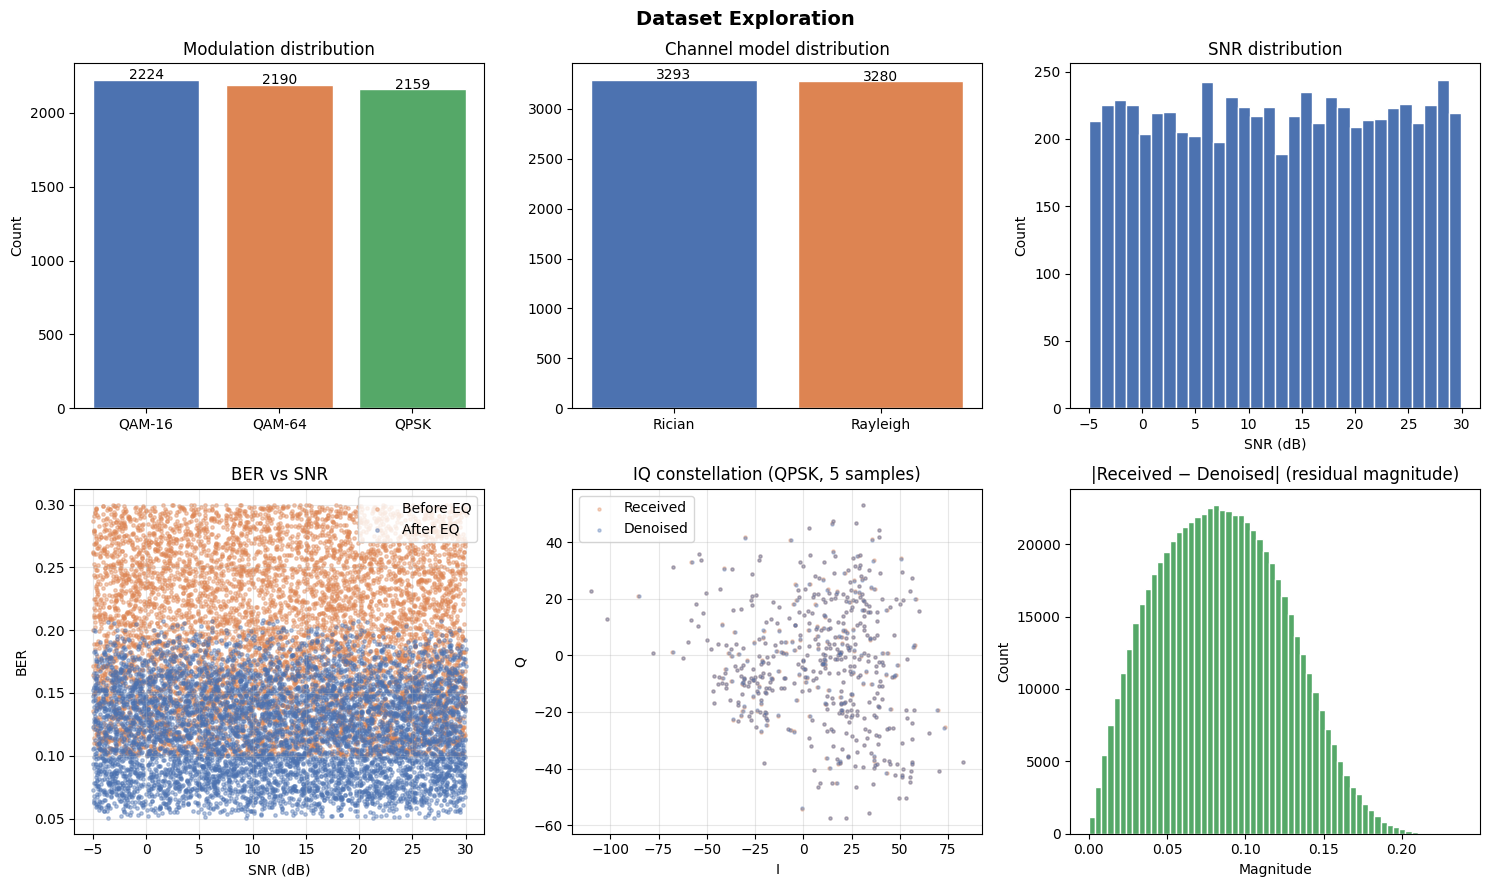

In [5]:
PALETTE = ['#4C72B0', '#DD8452', '#55A868']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Dataset Exploration', fontsize=14, fontweight='bold')

vc = df_orig.Modulation_Type.value_counts()
axes[0,0].bar(vc.index, vc.values, color=PALETTE, edgecolor='white')
axes[0,0].set_title('Modulation distribution'); axes[0,0].set_ylabel('Count')
for bar, v in zip(axes[0,0].patches, vc.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha='center')

vc2 = df_orig.Channel_Model.value_counts()
axes[0,1].bar(vc2.index, vc2.values, color=PALETTE[:2], edgecolor='white')
axes[0,1].set_title('Channel model distribution')
for bar, v in zip(axes[0,1].patches, vc2.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha='center')

axes[0,2].hist(df_orig.SNR_dB, bins=30, color=PALETTE[0], edgecolor='white')
axes[0,2].set_title('SNR distribution')
axes[0,2].set_xlabel('SNR (dB)'); axes[0,2].set_ylabel('Count')

axes[1,0].scatter(df_orig.SNR_dB, df_orig.BER_Before, s=6, alpha=0.4,
                  color='#DD8452', label='Before EQ')
axes[1,0].scatter(df_orig.SNR_dB, df_orig.BER_After, s=6, alpha=0.4,
                  color='#4C72B0', label='After EQ')
axes[1,0].set_xlabel('SNR (dB)'); axes[1,0].set_ylabel('BER')
axes[1,0].set_title('BER vs SNR'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

qidx = np.where(df_orig.Modulation_Type == 'QPSK')[0][:5]
rx_q = rx_orig[qidx].flatten(); dn_q = dn_orig[qidx].flatten()
axes[1,1].scatter(rx_q.real, rx_q.imag, s=5, alpha=0.35, color='#DD8452', label='Received')
axes[1,1].scatter(dn_q.real, dn_q.imag, s=5, alpha=0.35, color='#4C72B0', label='Denoised')
axes[1,1].set_title('IQ constellation (QPSK, 5 samples)')
axes[1,1].set_xlabel('I'); axes[1,1].set_ylabel('Q')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

axes[1,2].hist(np.abs(res_orig).flatten(), bins=60, color='#55A868', edgecolor='white')
axes[1,2].set_title('|Received − Denoised| (residual magnitude)')
axes[1,2].set_xlabel('Magnitude'); axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
def build_Xy(df_in, rx_in, dn_in, fit_scalers=False):
    """
    Build feature matrix X (N, 203) and target matrix y (N, 200) from raw arrays.

    Parameters
    ----------
    df_in        : DataFrame with Modulation_Type, Channel_Model, SNR_dB columns
    rx_in        : complex128 array (N, 100) — received signals
    dn_in        : complex128 array (N, 100) — denoised signals
    fit_scalers  : if True, fit new scalers and store them as globals;
                   if False, use the already-fitted globals (for augmented data)

    Returns
    -------
    X : float32 (N, 203)
    y : float32 (N, 200)
    """
    global mod_enc, ch_enc, meta_scaler, sig_scaler, res_scaler

    assert len(df_in) == len(rx_in) == len(dn_in), 'Row count mismatch'

    res_in = dn_in - rx_in

    mod_c = mod_enc.transform(df_in['Modulation_Type']).astype(np.float32)
    ch_c  = ch_enc.transform(df_in['Channel_Model']).astype(np.float32)
    snr_v = df_in['SNR_dB'].values.astype(np.float32)

    meta_raw = np.stack([mod_c, ch_c, snr_v], axis=1)
    rx_2d    = np.concatenate([rx_in.real, rx_in.imag], axis=1).astype(np.float32)
    res_2d   = np.concatenate([res_in.real, res_in.imag], axis=1).astype(np.float32)

    if fit_scalers:
        meta_scaler = StandardScaler().fit(meta_raw)
        sig_scaler  = StandardScaler().fit(rx_2d)
        res_scaler  = StandardScaler().fit(res_2d)
        print(f'  Scalers fitted on {len(df_in)} samples')

    X = np.concatenate([
        meta_scaler.transform(meta_raw),
        sig_scaler.transform(rx_2d)
    ], axis=1).astype(np.float32)

    y = res_scaler.transform(res_2d).astype(np.float32)
    return X, y


def to_original_scale(y_norm):
    return res_scaler.inverse_transform(y_norm)


# ── Fit encoders once (reused in all parts) ───────────────────────────────
mod_enc = LabelEncoder().fit(df_orig['Modulation_Type'])
ch_enc  = LabelEncoder().fit(df_orig['Channel_Model'])
print('Modulation encoding:', dict(zip(mod_enc.classes_,
                                        mod_enc.transform(mod_enc.classes_))))
print('Channel encoding   :', dict(zip(ch_enc.classes_,
                                        ch_enc.transform(ch_enc.classes_))))

# ── Build X, y for Part A ─────────────────────────────────────────────────
print('\nBuilding Part A (original) feature matrices...')
X_a, y_a = build_Xy(df_orig, rx_orig, dn_orig, fit_scalers=True)
print(f'X_a : {X_a.shape}   range [{X_a.min():.2f}, {X_a.max():.2f}]')
print(f'y_a : {y_a.shape}   range [{y_a.min():.2f}, {y_a.max():.2f}]')

# ── Train / Val / Test split ──────────────────────────────────────────────
# new — 72 / 8 / 20  (satisfies 80:20 train:test requirement)
idx_all_a            = np.arange(len(df_orig))
idx_tr_tmp, idx_te_a = train_test_split(idx_all_a, test_size=0.20, random_state=SEED)
idx_tr_a, idx_val_a  = train_test_split(idx_tr_tmp, test_size=0.10, random_state=SEED)

X_tr_a,  y_tr_a  = X_a[idx_tr_a],  y_a[idx_tr_a]
X_val_a, y_val_a = X_a[idx_val_a], y_a[idx_val_a]
X_te_a,  y_te_a  = X_a[idx_te_a],  y_a[idx_te_a]

print(f'Train : {len(idx_tr_a)}   Val : {len(idx_val_a)}   Test : {len(idx_te_a)}')

Modulation encoding: {'QAM-16': np.int64(0), 'QAM-64': np.int64(1), 'QPSK': np.int64(2)}
Channel encoding   : {'Rayleigh': np.int64(0), 'Rician': np.int64(1)}

Building Part A (original) feature matrices...
  Scalers fitted on 6573 samples
X_a : (6573, 203)   range [-12.68, 18.72]
y_a : (6573, 200)   range [-3.49, 3.58]
Train : 4732   Val : 526   Test : 1315


In [7]:
class EqDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def make_loader(X, y, shuffle):
    return DataLoader(
        EqDataset(X, y),
        batch_size  = BATCH_SIZE,
        shuffle     = shuffle,
        num_workers = 2,
        pin_memory  = (DEVICE.type == 'cuda'),
    )


tr_loader_a  = make_loader(X_tr_a,  y_tr_a,  shuffle=True)
val_loader_a = make_loader(X_val_a, y_val_a, shuffle=False)
te_loader_a  = make_loader(X_te_a,  y_te_a,  shuffle=False)

Xb, yb = next(iter(tr_loader_a))
print(f'Batch X : {tuple(Xb.shape)}  {Xb.dtype}')
print(f'Batch y : {tuple(yb.shape)}  {yb.dtype}')

Batch X : (256, 203)  torch.float32
Batch y : (256, 200)  torch.float32


In [8]:
# ── Shared block ──────────────────────────────────────────────────────────
class FCBlock(nn.Module):
    def __init__(self, in_d, out_d, dropout=DROPOUT):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_d, out_d), nn.BatchNorm1d(out_d), nn.GELU(), nn.Dropout(dropout))
    def forward(self, x): return self.block(x)


# ── MLP ───────────────────────────────────────────────────────────────────
class MLPEqualizer(nn.Module):
    def __init__(self, in_dim=IN_DIM, out_dim=OUT_DIM, hidden=HIDDEN, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            FCBlock(in_dim,    hidden,    dropout),
            FCBlock(hidden,    hidden,    dropout),
            FCBlock(hidden,    hidden,    dropout),
            FCBlock(hidden,    hidden//2, dropout),
            FCBlock(hidden//2, hidden//2, dropout),
            nn.Linear(hidden//2, out_dim),
        )
    def forward(self, x): return self.net(x)


# ── ResNet ────────────────────────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=DROPOUT):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(dim), nn.GELU(), nn.Linear(dim, dim),
            nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(dim, dim))
    def forward(self, x): return x + self.block(x)


class ResNetEqualizer(nn.Module):
    def __init__(self, in_dim=IN_DIM, out_dim=OUT_DIM,
                 hidden=HIDDEN, n_blocks=N_BLOCKS, dropout=DROPOUT):
        super().__init__()
        self.embed  = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.GELU())
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head   = nn.Sequential(
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Linear(hidden, out_dim))
    def forward(self, x): return self.head(self.blocks(self.embed(x)))


# ── FiLM-ResNet ───────────────────────────────────────────────────────────
class FiLMLayer(nn.Module):
    def __init__(self, feat_dim, meta_dim=META_DIM, hidden_meta=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(meta_dim, hidden_meta), nn.GELU(),
            nn.Linear(hidden_meta, feat_dim * 2))
        nn.init.zeros_(self.net[-1].weight)
        with torch.no_grad():
            self.net[-1].bias[:feat_dim] = 1.0
            self.net[-1].bias[feat_dim:] = 0.0
    def forward(self, h, meta):
        g, b = self.net(meta).chunk(2, dim=-1)
        return g * h + b


class FiLMResBlock(nn.Module):
    def __init__(self, dim, meta_dim=META_DIM, dropout=DROPOUT):
        super().__init__()
        self.bn1  = nn.BatchNorm1d(dim); self.fc1  = nn.Linear(dim, dim)
        self.film = FiLMLayer(dim, meta_dim)
        self.bn2  = nn.BatchNorm1d(dim); self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(dim, dim); self.act  = nn.GELU()
    def forward(self, h, meta):
        out = self.fc1(self.act(self.bn1(h)))
        out = self.film(out, meta)
        out = self.drop(self.fc2(self.act(self.bn2(out))))
        return h + out


class FiLMResNetEqualizer(nn.Module):
    def __init__(self, in_dim=IN_DIM, out_dim=OUT_DIM, meta_dim=META_DIM,
                 hidden=HIDDEN, n_blocks=N_BLOCKS, dropout=DROPOUT):
        super().__init__()
        self.meta_dim  = meta_dim
        self.sig_embed = nn.Sequential(
            nn.Linear(in_dim - meta_dim, hidden), nn.BatchNorm1d(hidden), nn.GELU())
        self.blocks    = nn.ModuleList(
            [FiLMResBlock(hidden, meta_dim, dropout) for _ in range(n_blocks)])
        self.head      = nn.Sequential(
            nn.BatchNorm1d(hidden), nn.GELU(), nn.Linear(hidden, out_dim))
    def forward(self, x):
        meta = x[:, :self.meta_dim]; signal = x[:, self.meta_dim:]
        h = self.sig_embed(signal)
        for block in self.blocks: h = block(h, meta)
        return self.head(h)


for name, cls in [('MLP', MLPEqualizer), ('ResNet', ResNetEqualizer),
                   ('FiLM-ResNet', FiLMResNetEqualizer)]:
    p = sum(pp.numel() for pp in cls().parameters() if pp.requires_grad)
    print(f'{name:<15}  params: {p:>10,}')

MLP              params:    261,064
ResNet           params:    635,080
FiLM-ResNet      params:    768,456


In [9]:
def run_epoch(model, loader, optimizer, criterion, training):
    model.train() if training else model.eval()
    total = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            pred = model(Xb); loss = criterion(pred, yb)
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total += loss.item() * len(Xb)
    return total / len(loader.dataset)


def train_model(model, name, tr_ld, val_ld):
    """
    Train with AdamW + CosineAnnealingLR + early stopping.
    Accepts loaders explicitly so it can be used by all three parts.
    Returns loss history dict.
    """
    criterion = nn.HuberLoss(delta=0.5)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=LR / 50)

    history = {'train': [], 'val': []}
    best_val = float('inf'); wait = 0; ckpt = f'{name}_best.pt'

    print(f'\n{"-"*60}')
    print(f'  Training: {name}')
    print(f'{"-"*60}')
    print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>12}  {"LR":>10}')
    print(f'{"-"*44}')

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        tr_l  = run_epoch(model, tr_ld,  optimizer, criterion, True)
        val_l = run_epoch(model, val_ld, optimizer, criterion, False)
        scheduler.step()
        history['train'].append(tr_l); history['val'].append(val_l)
        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:>6d}  {tr_l:>12.7f}  {val_l:>12.7f}  '
                  f'{scheduler.get_last_lr()[0]:>10.2e}')
        if val_l < best_val:
            best_val = val_l; wait = 0
            torch.save(model.state_dict(), ckpt)
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f'  Early stop at epoch {epoch}  (best val={best_val:.7f})')
                break
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    print(f'  Time: {time.time()-t0:.0f}s   Best val loss: {best_val:.7f}')
    return history


@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds, tgts = [], []
    for Xb, yb in loader:
        preds.append(model(Xb.to(DEVICE)).cpu().numpy())
        tgts.append(yb.numpy())
    return np.vstack(preds), np.vstack(tgts)


def compute_metrics(y_pred_n, y_true_n, label=''):
    yt = to_original_scale(y_true_n)
    yp = to_original_scale(y_pred_n)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    nmse = np.sum((yp-yt)**2) / (np.sum(yt**2) + 1e-12)
    nmse_db = 10 * np.log10(nmse + 1e-12)
    if label:
        print(f'  ┌─ {label}')
        print(f'  │  MSE  : {mse:.8f}   RMSE : {rmse:.8f}')
        print(f'  │  MAE  : {mae:.8f}   R²   : {r2:.6f}')
        print(f'  └  NMSE : {nmse_db:+.3f} dB')
    return dict(MSE=mse, RMSE=rmse, MAE=mae, R2=r2, NMSE_dB=nmse_db)


print('Utilities ready.')

Utilities ready.


---
# Part A — Baseline

Trains MLP, ResNet, and FiLM-ResNet on the original 6,573 samples. Establishes the performance baseline.


In [10]:
all_histories_a = {}
all_results_a   = {}

for name, cls in [('MLP', MLPEqualizer), ('ResNet', ResNetEqualizer),
                   ('FiLM-ResNet', FiLMResNetEqualizer)]:
    model   = cls().to(DEVICE)
    history = train_model(model, f'A_{name}', tr_loader_a, val_loader_a)
    all_histories_a[name] = history
    y_pred_n, y_true_n = predict(model, te_loader_a)
    m = compute_metrics(y_pred_n, y_true_n, label=f'{name} — Part A Test')
    all_results_a[name] = (model, y_pred_n, y_true_n, m)


------------------------------------------------------------
  Training: A_MLP
------------------------------------------------------------
 Epoch    Train Loss      Val Loss          LR
--------------------------------------------
     1     0.3154062     0.2979927    1.00e-03
    10     0.2970683     0.2974240    9.97e-04
    20     0.2955658     0.2954085    9.89e-04
    30     0.2900982     0.2893658    9.76e-04
    40     0.2860056     0.2857584    9.58e-04
    50     0.2834499     0.2836643    9.34e-04
    60     0.2817898     0.2823411    9.06e-04
    70     0.2804519     0.2814626    8.74e-04
    80     0.2794875     0.2807664    8.38e-04
    90     0.2789211     0.2805020    7.98e-04
   100     0.2780644     0.2799353    7.55e-04
   110     0.2776705     0.2796855    7.09e-04
   120     0.2770930     0.2794442    6.61e-04
   130     0.2766597     0.2793017    6.12e-04
   140     0.2765282     0.2791247    5.61e-04
   150     0.2761093     0.2789500    5.10e-04
   160     0.27

In [11]:
rows_a = [{'Model': n, **m} for n, (_, _, _, m) in all_results_a.items()]
cmp_a  = pd.DataFrame(rows_a).set_index('Model')

print('\n' + '='*65)
print('  PART A — Baseline Results (original 6,573 samples)')
print('='*65)
print(cmp_a.to_string(float_format=lambda x: f'{x:.6f}'))

best_name_a = cmp_a['RMSE'].idxmin()
print(f'\n  ✓  Best model : {best_name_a}  '
      f'(RMSE={cmp_a.loc[best_name_a,"RMSE"]:.8f}, '
      f'NMSE={cmp_a.loc[best_name_a,"NMSE_dB"]:+.3f} dB)')


  PART A — Baseline Results (original 6,573 samples)
                 MSE     RMSE      MAE       R2   NMSE_dB
Model                                                    
MLP         0.004009 0.063314 0.050874 0.084098 -0.409903
ResNet      0.001760 0.041954 0.032863 0.601929 -3.984458
FiLM-ResNet 0.001761 0.041969 0.032958 0.602526 -3.981489

  ✓  Best model : ResNet  (RMSE=0.04195418, NMSE=-3.984 dB)


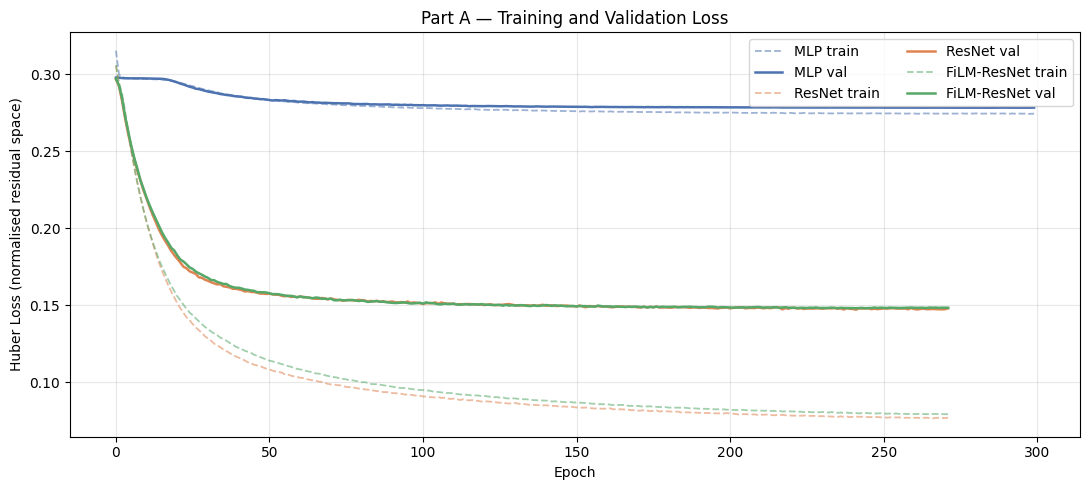

In [12]:
COLORS = {'MLP': '#4C72B0', 'ResNet': '#DD8452', 'FiLM-ResNet': '#55A868'}

# Training curves
fig, ax = plt.subplots(figsize=(11, 5))
for name, h in all_histories_a.items():
    c = COLORS[name]
    ax.plot(h['train'], '--', color=c, alpha=0.55, lw=1.3, label=f'{name} train')
    ax.plot(h['val'],   '-',  color=c, lw=1.8,             label=f'{name} val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss (normalised residual space)')
ax.set_title('Part A — Training and Validation Loss')
ax.legend(ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('partA_training_curves.png', dpi=120); plt.show()

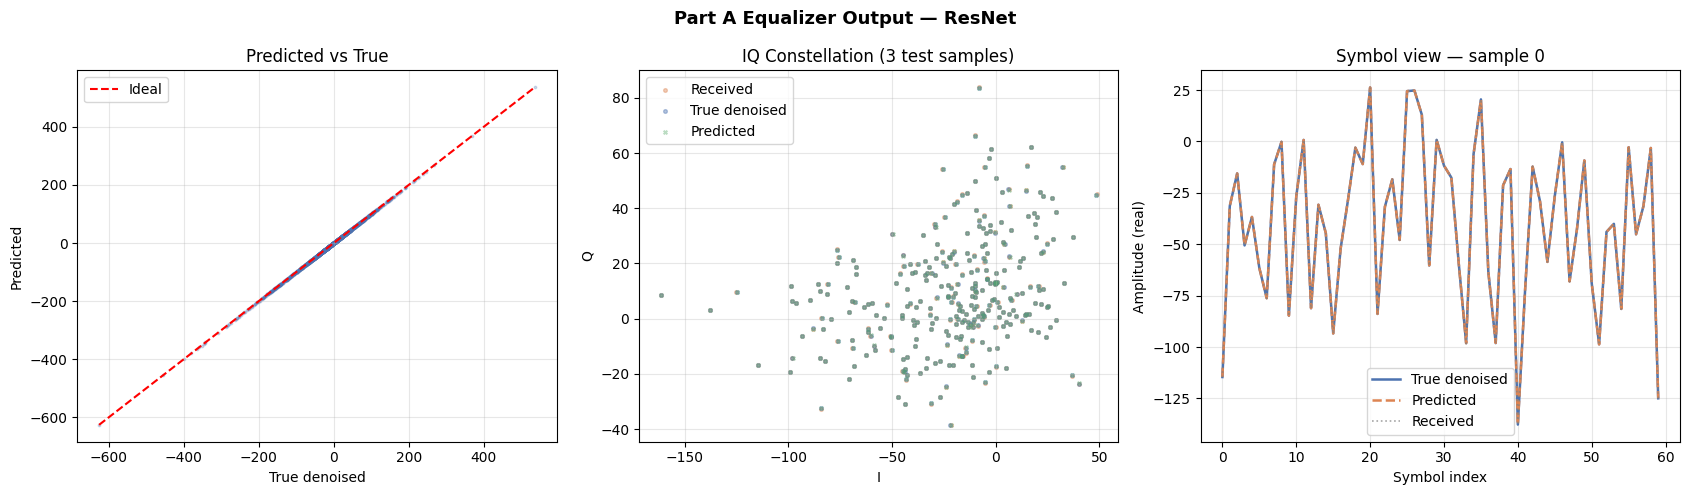

In [13]:
# Equalizer output plots — best model
best_model_a, y_pred_n_a, y_true_n_a, _ = all_results_a[best_name_a]
y_pred_orig_a = to_original_scale(y_pred_n_a)
y_true_orig_a = to_original_scale(y_true_n_a)
rx_te_raw_a   = sig_scaler.inverse_transform(X_te_a[:, META_DIM:])
dn_pred_a     = rx_te_raw_a + y_pred_orig_a
dn_true_a     = rx_te_raw_a + y_true_orig_a

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Part A Equalizer Output — {best_name_a}', fontsize=13, fontweight='bold')

n_pts = min(3000, dn_pred_a.size)
flat_t = dn_true_a.flatten()[:n_pts]; flat_p = dn_pred_a.flatten()[:n_pts]
axes[0].scatter(flat_t, flat_p, s=3, alpha=0.25, color='#4C72B0')
lo, hi = min(flat_t.min(), flat_p.min()), max(flat_t.max(), flat_p.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Ideal')
axes[0].set_xlabel('True denoised'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs True'); axes[0].legend(); axes[0].grid(alpha=0.3)

s = slice(0, 3)
axes[1].scatter(rx_te_raw_a[s,:N_SIGNALS].flatten(),
                rx_te_raw_a[s,N_SIGNALS:].flatten(),
                s=7, alpha=0.4, color='#DD8452', label='Received')
axes[1].scatter(dn_true_a[s,:N_SIGNALS].flatten(),
                dn_true_a[s,N_SIGNALS:].flatten(),
                s=7, alpha=0.4, color='#4C72B0', label='True denoised')
axes[1].scatter(dn_pred_a[s,:N_SIGNALS].flatten(),
                dn_pred_a[s,N_SIGNALS:].flatten(),
                s=7, alpha=0.4, color='#55A868', label='Predicted', marker='x')
axes[1].set_xlabel('I'); axes[1].set_ylabel('Q')
axes[1].set_title('IQ Constellation (3 test samples)')
axes[1].legend(); axes[1].grid(alpha=0.3)

k = 0
axes[2].plot(dn_true_a[k,:60], '-',  color='#4C72B0', lw=1.8, label='True denoised')
axes[2].plot(dn_pred_a[k,:60], '--', color='#DD8452', lw=1.8, label='Predicted')
axes[2].plot(rx_te_raw_a[k,:60], ':', color='gray', lw=1.2, alpha=0.7, label='Received')
axes[2].set_xlabel('Symbol index'); axes[2].set_ylabel('Amplitude (real)')
axes[2].set_title('Symbol view — sample 0'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('partA_equalizer_output.png', dpi=120, bbox_inches='tight')
plt.show()

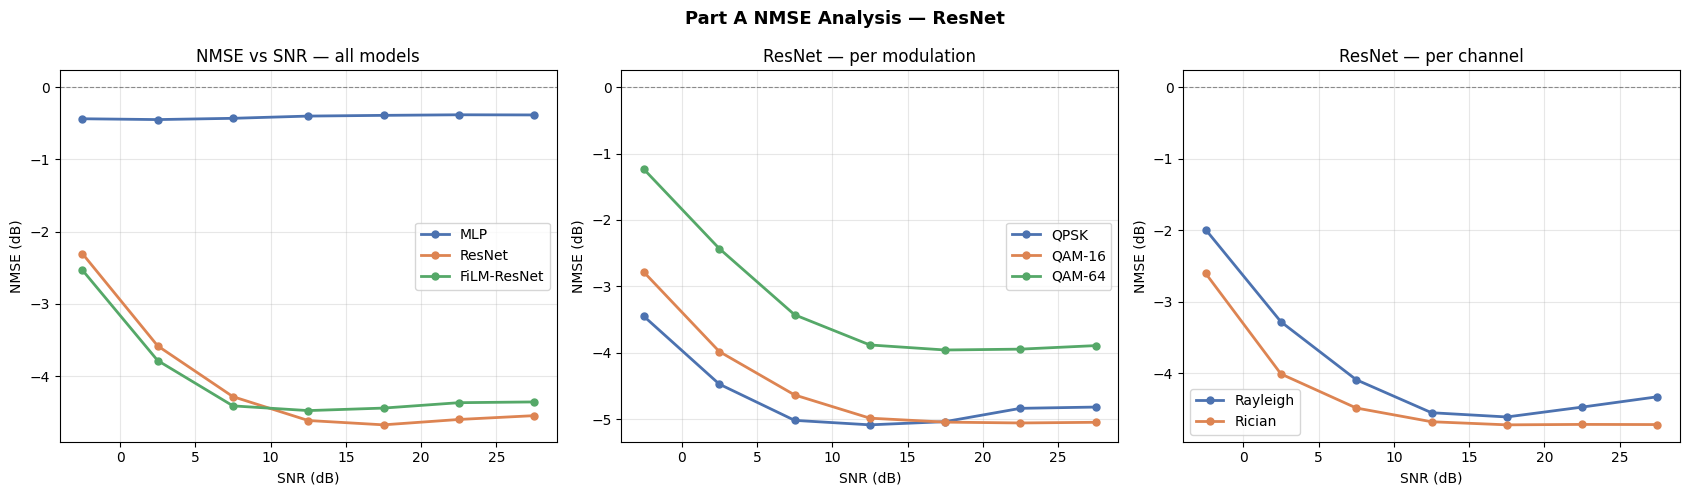

In [14]:
# NMSE vs SNR
snr_te_a  = df_orig['SNR_dB'].values[idx_te_a]
mods_te_a = df_orig['Modulation_Type'].values[idx_te_a]
chs_te_a  = df_orig['Channel_Model'].values[idx_te_a]

SNR_BINS = np.arange(-5, 35, 5)
SNR_MIDS = (SNR_BINS[:-1] + SNR_BINS[1:]) / 2

def nmse_by_snr(yp_n, yt_n, snr_vals):
    out = []
    for lo, hi in zip(SNR_BINS[:-1], SNR_BINS[1:]):
        mask = (snr_vals >= lo) & (snr_vals < hi)
        if mask.sum() < 2: out.append(np.nan); continue
        yt = to_original_scale(yt_n[mask]); yp = to_original_scale(yp_n[mask])
        nmse = np.sum((yp-yt)**2) / (np.sum(yt**2) + 1e-12)
        out.append(10 * np.log10(nmse + 1e-12))
    return np.array(out)


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Part A NMSE Analysis — {best_name_a}', fontsize=13, fontweight='bold')

for name, (_, yp, yt, _) in all_results_a.items():
    axes[0].plot(SNR_MIDS, nmse_by_snr(yp, yt, snr_te_a),
                 'o-', color=COLORS[name], lw=2, ms=5, label=name)
axes[0].set_xlabel('SNR (dB)'); axes[0].set_ylabel('NMSE (dB)')
axes[0].set_title('NMSE vs SNR — all models')
axes[0].axhline(0, color='k', ls='--', lw=0.8, alpha=0.4)
axes[0].legend(); axes[0].grid(alpha=0.3)

_, yp_b_a, yt_b_a, _ = all_results_a[best_name_a]
for mod, col in zip(['QPSK','QAM-16','QAM-64'], PALETTE):
    mask = mods_te_a == mod
    if mask.sum() < 2: continue
    axes[1].plot(SNR_MIDS, nmse_by_snr(yp_b_a[mask], yt_b_a[mask], snr_te_a[mask]),
                 'o-', color=col, lw=2, ms=5, label=mod)
axes[1].set_xlabel('SNR (dB)'); axes[1].set_ylabel('NMSE (dB)')
axes[1].set_title(f'{best_name_a} — per modulation')
axes[1].axhline(0, color='k', ls='--', lw=0.8, alpha=0.4)
axes[1].legend(); axes[1].grid(alpha=0.3)

for ch, col in zip(['Rayleigh','Rician'], PALETTE[:2]):
    mask = chs_te_a == ch
    if mask.sum() < 2: continue
    axes[2].plot(SNR_MIDS, nmse_by_snr(yp_b_a[mask], yt_b_a[mask], snr_te_a[mask]),
                 'o-', color=col, lw=2, ms=5, label=ch)
axes[2].set_xlabel('SNR (dB)'); axes[2].set_ylabel('NMSE (dB)')
axes[2].set_title(f'{best_name_a} — per channel')
axes[2].axhline(0, color='k', ls='--', lw=0.8, alpha=0.4)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('partA_nmse.png', dpi=120, bbox_inches='tight'); plt.show()

---
# Part B — Phase-Rotation Augmentation

Phase rotation is a physically valid augmentation for complex wireless signals. Multiplying a complex signal by e^(jθ) is equivalent to a different carrier phase offset at the transmitter — the noise statistics, channel type, and equalization residual all remain valid under the same rotation.
Three rotation angles are applied to the training split only, growing it from 4,732 to 18,928 samples (4×). The best model from Part A is then retrained on this augmented set.


In [15]:
# ── Only augment the TRAINING split, not val or test ────────────────────
# This is the correct way — augmenting the test set would be data leakage.

AUGMENT_ANGLES = [np.pi/6, np.pi/3, np.pi/2]   # 3 extra rotations → 4× train data

def augment_train(rx_tr, dn_tr, df_tr, angles):
    """Apply phase rotations to training data only."""
    rx_list = [rx_tr]; dn_list = [dn_tr]; df_list = [df_tr]
    for theta in angles:
        rot = np.exp(1j * theta)
        rx_list.append(rx_tr * rot)
        dn_list.append(dn_tr * rot)
        df_list.append(df_tr.copy())
    rx_aug = np.vstack(rx_list)
    dn_aug = np.vstack(dn_list)
    df_aug = pd.concat(df_list, ignore_index=True)
    print(f'  Train samples: {len(rx_tr)} → {len(rx_aug)}  ({len(angles)+1}× augmentation)')
    return rx_aug, dn_aug, df_aug


# Extract original training samples
rx_tr_orig = rx_orig[idx_tr_a]
dn_tr_orig = dn_orig[idx_tr_a]
df_tr_orig = df_orig.iloc[idx_tr_a].reset_index(drop=True)

# Augment
print('Building augmented training set...')
rx_tr_aug, dn_tr_aug, df_tr_aug = augment_train(
    rx_tr_orig, dn_tr_orig, df_tr_orig, AUGMENT_ANGLES)

# Val and Test are UNCHANGED from Part A
rx_val_orig = rx_orig[idx_val_a]
dn_val_orig = dn_orig[idx_val_a]
df_val_orig = df_orig.iloc[idx_val_a].reset_index(drop=True)

print(f'Val  samples: {len(rx_val_orig)}  (unchanged)')
print(f'Test samples: {len(idx_te_a)}    (unchanged — same as Part A)')

Building augmented training set...
  Train samples: 4732 → 18928  (4× augmentation)
Val  samples: 526  (unchanged)
Test samples: 1315    (unchanged — same as Part A)


In [16]:
# Scalers were already fitted on the ORIGINAL full dataset in Part A.
# We reuse them here — do NOT refit on augmented data.

print('Building augmented feature matrices (using Part A scalers)...')
X_tr_aug,  y_tr_aug  = build_Xy(df_tr_aug,  rx_tr_aug,  dn_tr_aug,  fit_scalers=False)
X_val_b,   y_val_b   = build_Xy(df_val_orig, rx_val_orig, dn_val_orig, fit_scalers=False)

# Test set is exactly the same as Part A
X_te_b = X_te_a;  y_te_b = y_te_a

print(f'X_tr_aug : {X_tr_aug.shape}')
print(f'X_val_b  : {X_val_b.shape}')
print(f'X_te_b   : {X_te_b.shape}  (same as Part A test)')

tr_loader_b  = make_loader(X_tr_aug, y_tr_aug, shuffle=True)
val_loader_b = make_loader(X_val_b,  y_val_b,  shuffle=False)
te_loader_b  = make_loader(X_te_b,   y_te_b,   shuffle=False)

Building augmented feature matrices (using Part A scalers)...
X_tr_aug : (18928, 203)
X_val_b  : (526, 203)
X_te_b   : (1315, 203)  (same as Part A test)


In [17]:
# Train only the best model from Part A on the augmented data.
# This directly answers: does augmentation help the best architecture?

print(f'Retraining {best_name_a} on augmented training set...\n')

aug_model_cls = {'MLP': MLPEqualizer,
                 'ResNet': ResNetEqualizer,
                 'FiLM-ResNet': FiLMResNetEqualizer}[best_name_a]

model_b  = aug_model_cls().to(DEVICE)
history_b = train_model(model_b, f'B_{best_name_a}', tr_loader_b, val_loader_b)

y_pred_n_b, y_true_n_b = predict(model_b, te_loader_b)
metrics_b = compute_metrics(y_pred_n_b, y_true_n_b,
                             label=f'{best_name_a} (Augmented) — Test Set')

Retraining ResNet on augmented training set...


------------------------------------------------------------
  Training: B_ResNet
------------------------------------------------------------
 Epoch    Train Loss      Val Loss          LR
--------------------------------------------
     1     0.2987796     0.2743855    1.00e-03
    10     0.1424262     0.1512281    9.97e-04
    20     0.1215663     0.1386525    9.89e-04
    30     0.1139383     0.1353210    9.76e-04
    40     0.1098760     0.1334140    9.58e-04
    50     0.1070232     0.1329323    9.34e-04
    60     0.1052098     0.1318636    9.06e-04
    70     0.1039050     0.1322246    8.74e-04
    80     0.1026779     0.1316378    8.38e-04
    90     0.1015228     0.1314016    7.98e-04
   100     0.1006466     0.1315169    7.55e-04
   110     0.0997728     0.1313252    7.09e-04
   120     0.0991406     0.1309925    6.61e-04
   130     0.0984035     0.1309056    6.12e-04
   140     0.0978362     0.1305515    5.61e-04
   150     

In [18]:
metrics_a_best = all_results_a[best_name_a][3]

print('\n' + '='*65)
print(f'  PART A vs PART B — {best_name_a} on same test set')
print('='*65)
print(f'{"":30} {"Part A (orig)":>16} {"Part B (aug)":>14}')
print('-'*62)
for k in ['MSE', 'RMSE', 'MAE', 'R2', 'NMSE_dB']:
    va = metrics_a_best[k]; vb = metrics_b[k]
    better = '✓ better' if (vb < va and k != 'R2') or (vb > va and k == 'R2') else ''
    print(f'  {k:<28} {va:>16.6f} {vb:>14.6f}  {better}')

diff_nmse = metrics_b['NMSE_dB'] - metrics_a_best['NMSE_dB']
print(f'\n  NMSE change from augmentation: {diff_nmse:+.3f} dB')
print(f'  (negative = augmentation helped; positive = augmentation hurt)')


  PART A vs PART B — ResNet on same test set
                                  Part A (orig)   Part B (aug)
--------------------------------------------------------------
  MSE                                  0.001760       0.001457  ✓ better
  RMSE                                 0.041954       0.038170  ✓ better
  MAE                                  0.032863       0.029957  ✓ better
  R2                                   0.601929       0.663893  ✓ better
  NMSE_dB                             -3.984458      -4.805456  ✓ better

  NMSE change from augmentation: -0.821 dB
  (negative = augmentation helped; positive = augmentation hurt)


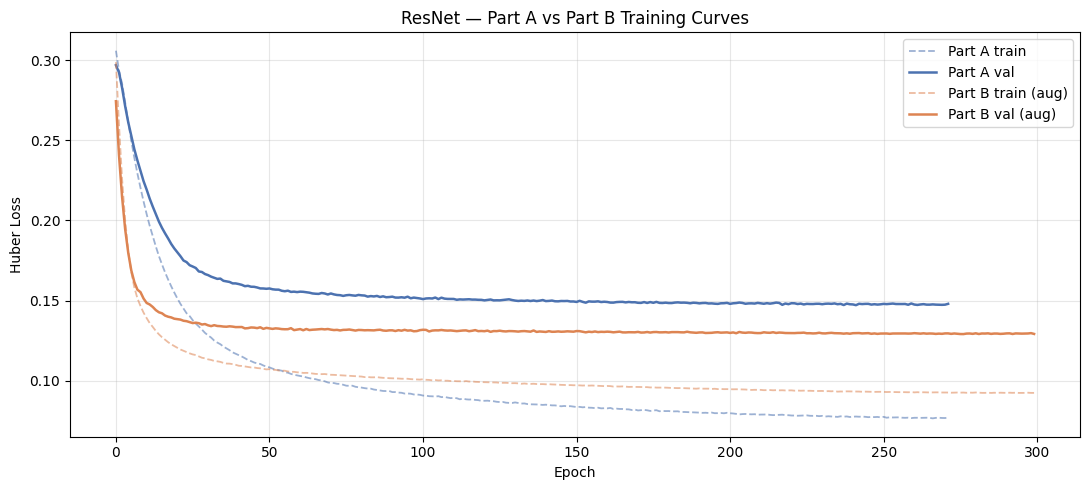

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ha = all_histories_a[best_name_a]
ax.plot(ha['train'], '--', color='#4C72B0', alpha=0.55, lw=1.3, label='Part A train')
ax.plot(ha['val'],   '-',  color='#4C72B0', lw=1.8,             label='Part A val')
ax.plot(history_b['train'], '--', color='#DD8452', alpha=0.55, lw=1.3, label='Part B train (aug)')
ax.plot(history_b['val'],   '-',  color='#DD8452', lw=1.8,             label='Part B val (aug)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.set_title(f'{best_name_a} — Part A vs Part B Training Curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('partB_training_curves.png', dpi=120); plt.show()

---
# Part C — Specialist Models (One Per Modulation)

**Strategy**: Instead of one joint model learning QPSK + QAM-16 + QAM-64 simultaneously, train three separate ResNets — one per modulation. Each specialist only sees one type of signal and learns its specific equalization pattern.

**Why this should help**: QPSK has 4 constellation points; QAM-64 has 64. Their noise characteristics, signal power levels, and optimal equalizer responses are fundamentally different. A joint model must average across all of them with shared weights.

**Test set**: Each specialist is tested on its own modulation's held-out samples.  
A combined overall metric is also computed for fair comparison with Parts A and B.


In [20]:
# Each specialist uses the ORIGINAL data (no augmentation) on its own modulation.
# The df and arrays are already clean (df_orig, rx_orig, dn_orig).

MODULATIONS = ['QPSK', 'QAM-16', 'QAM-64']

specialist_models  = {}
specialist_results = {}
specialist_hist    = {}

print('Training specialist models (one per modulation)...\n')

for mod in MODULATIONS:
    print(f'{'='*55}')
    print(f'  Modulation: {mod}')

    # Get indices for this modulation — guaranteed in range 0..len(df_orig)-1
    mod_idx = np.where(df_orig['Modulation_Type'].values == mod)[0]
    assert mod_idx.max() < len(df_orig), f'Index out of bounds for {mod}'

    # # Split within this modulation
    # tr_i, tmp_i = train_test_split(mod_idx, test_size=0.20, random_state=SEED)
    # val_i, te_i = train_test_split(tmp_i,   test_size=0.50, random_state=SEED)

    # Split to match the global 72 / 8 / 20 scheme
    # Step 1 — carve out 20% as test
    tr_tmp_i, te_i = train_test_split(mod_idx, test_size=0.20, random_state=SEED)
    # Step 2 — split remaining 80% into train (90%) and val (10%)
    tr_i, val_i    = train_test_split(tr_tmp_i, test_size=0.10, random_state=SEED)
    
    print(f'  total={len(mod_idx)}  train={len(tr_i)}  val={len(val_i)}  test={len(te_i)}')

    # Build X, y using pre-fitted scalers from Part A (no refitting)
    X_tr_s,  y_tr_s  = build_Xy(df_orig.iloc[tr_i].reset_index(drop=True),
                                  rx_orig[tr_i], dn_orig[tr_i], fit_scalers=False)
    X_val_s, y_val_s = build_Xy(df_orig.iloc[val_i].reset_index(drop=True),
                                  rx_orig[val_i], dn_orig[val_i], fit_scalers=False)
    X_te_s,  y_te_s  = build_Xy(df_orig.iloc[te_i].reset_index(drop=True),
                                  rx_orig[te_i], dn_orig[te_i], fit_scalers=False)

    tr_ld  = make_loader(X_tr_s,  y_tr_s,  shuffle=True)
    val_ld = make_loader(X_val_s, y_val_s, shuffle=False)
    te_ld  = make_loader(X_te_s,  y_te_s,  shuffle=False)

    model   = ResNetEqualizer().to(DEVICE)
    history = train_model(model, f'C_ResNet_{mod}', tr_ld, val_ld)

    y_pred_n, y_true_n = predict(model, te_ld)
    m = compute_metrics(y_pred_n, y_true_n, label=f'ResNet specialist — {mod}')

    specialist_models[mod]  = model
    specialist_results[mod] = (y_pred_n, y_true_n, m, te_i)
    specialist_hist[mod]    = history

Training specialist models (one per modulation)...

  Modulation: QPSK
  total=2159  train=1554  val=173  test=432

------------------------------------------------------------
  Training: C_ResNet_QPSK
------------------------------------------------------------
 Epoch    Train Loss      Val Loss          LR
--------------------------------------------
     1     0.3156897     0.2970197    1.00e-03
    10     0.2672464     0.2801362    9.97e-04
    20     0.2304894     0.2617126    9.89e-04
    30     0.2008858     0.2474351    9.76e-04
    40     0.1792480     0.2353529    9.58e-04
    50     0.1592296     0.2240043    9.34e-04
    60     0.1435918     0.2165996    9.06e-04
    70     0.1314751     0.2078921    8.74e-04
    80     0.1209271     0.2026203    8.38e-04
    90     0.1121108     0.1984149    7.98e-04
   100     0.1048155     0.1919218    7.55e-04
   110     0.0976925     0.1902606    7.09e-04
   120     0.0926288     0.1865239    6.61e-04
   130     0.0884102     0.184840

In [21]:
print('\n' + '='*58)
print('  PART C — Specialist Model Results')
print('='*58)
print(f'{"Modulation":<12} {"N_test":>7} {"RMSE":>10} {"R²":>8} {"NMSE (dB)":>12}')
print('─'*52)

all_preds_c  = []; all_truths_c = []; all_nmse_c = []

for mod in MODULATIONS:
    yp, yt, m, te_i = specialist_results[mod]
    print(f'{mod:<12} {len(te_i):>7} {m["RMSE"]:>10.5f} '
          f'{m["R2"]:>8.3f} {m["NMSE_dB"]:>+12.3f}')
    all_preds_c.append(yp); all_truths_c.append(yt); all_nmse_c.append(m["NMSE_dB"])

y_pred_all_c = np.vstack(all_preds_c); y_true_all_c = np.vstack(all_truths_c)
m_all_c      = compute_metrics(y_pred_all_c, y_true_all_c)

print('─'*52)
print(f'{"Overall (combined)":<12} {len(y_pred_all_c):>7} {m_all_c["RMSE"]:>10.5f} '
      f'{m_all_c["R2"]:>8.3f} {m_all_c["NMSE_dB"]:>+12.3f}')
print(f'\nAverage NMSE across modulations: {np.mean(all_nmse_c):+.3f} dB')


  PART C — Specialist Model Results
Modulation    N_test       RMSE       R²    NMSE (dB)
────────────────────────────────────────────────────
QPSK             432    0.04706    0.495       -2.990
QAM-16           445    0.04723    0.493       -2.957
QAM-64           438    0.04604    0.519       -3.178
────────────────────────────────────────────────────
Overall (combined)    1315    0.04678    0.504       -3.040

Average NMSE across modulations: -3.041 dB


# Full Three-Part Comparison

In [22]:
print('\n' + '='*70)
print('  FINAL COMPARISON ACROSS ALL THREE PARTS')
print('='*70)
print(f'{"Approach":<35} {"RMSE":>10} {"R²":>8} {"NMSE (dB)":>12}')
print('─'*68)

# Part A — all three models
for name, (_, _, _, m) in all_results_a.items():
    print(f'  Part A — {name:<25} {m["RMSE"]:>10.5f} {m["R2"]:>8.3f} {m["NMSE_dB"]:>+12.3f}')

print()
# Part B — best model augmented
print(f'  Part B — {best_name_a} (augmented){"":<10} '
      f'{metrics_b["RMSE"]:>10.5f} {metrics_b["R2"]:>8.3f} {metrics_b["NMSE_dB"]:>+12.3f}')

print()
# Part C — specialist models (combined)
print(f'  Part C — ResNet specialists (combined)      '
      f'{m_all_c["RMSE"]:>10.5f} {m_all_c["R2"]:>8.3f} {m_all_c["NMSE_dB"]:>+12.3f}')
for mod in MODULATIONS:
    _, _, m, _ = specialist_results[mod]
    print(f'           ResNet specialist {mod:<14} '
          f'{m["RMSE"]:>10.5f} {m["R2"]:>8.3f} {m["NMSE_dB"]:>+12.3f}')

print('─'*68)


  FINAL COMPARISON ACROSS ALL THREE PARTS
Approach                                  RMSE       R²    NMSE (dB)
────────────────────────────────────────────────────────────────────
  Part A — MLP                          0.06331    0.084       -0.410
  Part A — ResNet                       0.04195    0.602       -3.984
  Part A — FiLM-ResNet                  0.04197    0.603       -3.981

  Part B — ResNet (augmented)              0.03817    0.664       -4.805

  Part C — ResNet specialists (combined)         0.04678    0.504       -3.040
           ResNet specialist QPSK              0.04706    0.495       -2.990
           ResNet specialist QAM-16            0.04723    0.493       -2.957
           ResNet specialist QAM-64            0.04604    0.519       -3.178
────────────────────────────────────────────────────────────────────


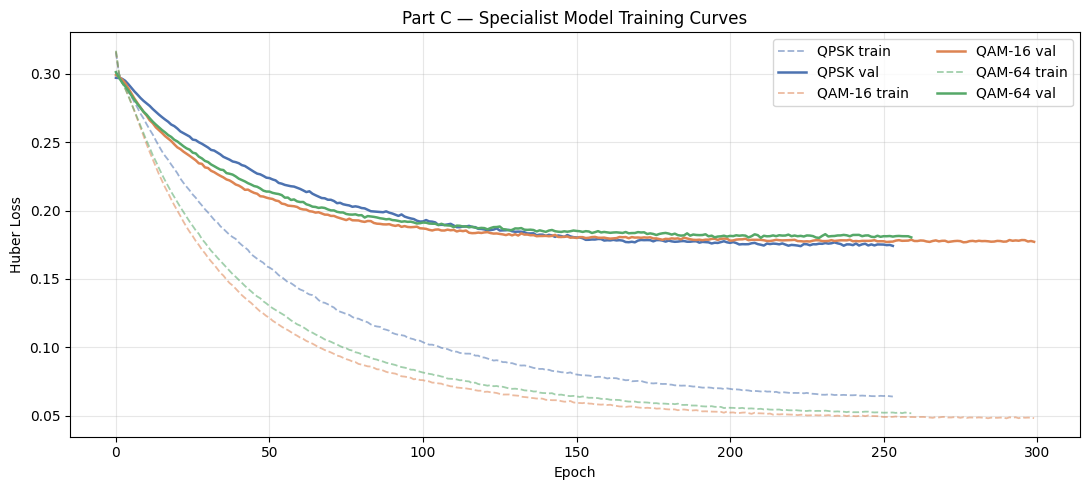

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
mod_colors = {'QPSK': '#4C72B0', 'QAM-16': '#DD8452', 'QAM-64': '#55A868'}
for mod, h in specialist_hist.items():
    c = mod_colors[mod]
    ax.plot(h['train'], '--', color=c, alpha=0.55, lw=1.3, label=f'{mod} train')
    ax.plot(h['val'],   '-',  color=c, lw=1.8,             label=f'{mod} val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.set_title('Part C — Specialist Model Training Curves')
ax.legend(ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('partC_training_curves.png', dpi=120); plt.show()

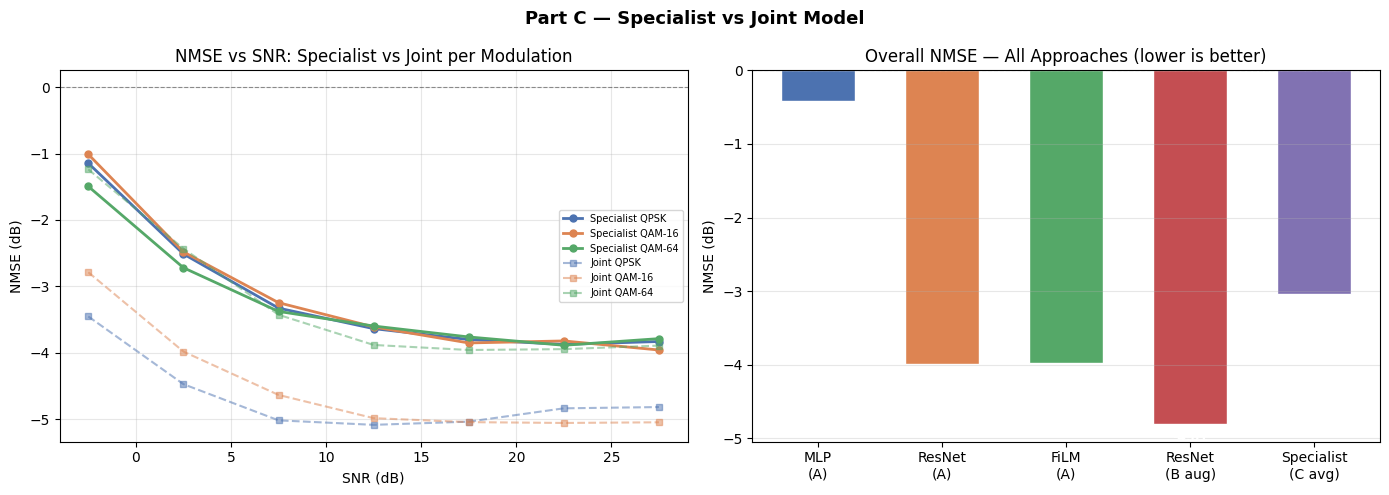

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part C — Specialist vs Joint Model', fontsize=13, fontweight='bold')

# Left: each specialist's NMSE vs SNR
for mod, col in zip(MODULATIONS, PALETTE):
    yp, yt, _, te_i = specialist_results[mod]
    snr_mod = df_orig['SNR_dB'].values[te_i]
    axes[0].plot(SNR_MIDS, nmse_by_snr(yp, yt, snr_mod),
                 'o-', color=col, lw=2, ms=5, label=f'Specialist {mod}')

# Overlay Part A best model per modulation (for comparison)
for mod, col in zip(MODULATIONS, PALETTE):
    mask_a = mods_te_a == mod
    if mask_a.sum() < 2: continue
    axes[0].plot(SNR_MIDS, nmse_by_snr(yp_b_a[mask_a], yt_b_a[mask_a], snr_te_a[mask_a]),
                 's--', color=col, lw=1.5, ms=4, alpha=0.5, label=f'Joint {mod}')

axes[0].set_xlabel('SNR (dB)'); axes[0].set_ylabel('NMSE (dB)')
axes[0].set_title('NMSE vs SNR: Specialist vs Joint per Modulation')
axes[0].axhline(0, color='k', ls='--', lw=0.8, alpha=0.4)
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

# Right: bar chart comparing overall NMSE across all approaches
approaches = ['MLP\n(A)', 'ResNet\n(A)', 'FiLM\n(A)',
              f'{best_name_a}\n(B aug)', 'Specialist\n(C avg)']
nmse_vals  = [
    all_results_a['MLP'][3]['NMSE_dB'],
    all_results_a['ResNet'][3]['NMSE_dB'],
    all_results_a['FiLM-ResNet'][3]['NMSE_dB'],
    metrics_b['NMSE_dB'],
    np.mean(all_nmse_c),
]
bar_colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
bars = axes[1].bar(approaches, nmse_vals, color=bar_colors, edgecolor='white', width=0.6)
axes[1].axhline(0, color='k', ls='--', lw=0.8, alpha=0.4)
axes[1].set_ylabel('NMSE (dB)')
axes[1].set_title('Overall NMSE — All Approaches (lower is better)')
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, nmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v-0.1, f'{v:.2f}',
                 ha='center', va='top', fontsize=9, fontweight='bold', color='white')

plt.tight_layout(); plt.savefig('partC_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Save Best Model & Inference

In [25]:
# Determine overall best across all parts
all_approaches = {
    **{f'A_{n}': all_results_a[n][3] for n in all_results_a},
    f'B_{best_name_a}': metrics_b,
    **{f'C_{mod}': specialist_results[mod][2] for mod in MODULATIONS},
}
overall_best_name = min(all_approaches, key=lambda k: all_approaches[k]['RMSE'])
overall_best_nmse = all_approaches[overall_best_name]['NMSE_dB']

print(f'Overall best approach : {overall_best_name}')
print(f'RMSE                  : {all_approaches[overall_best_name]["RMSE"]:.8f}')
print(f'NMSE                  : {overall_best_nmse:+.3f} dB')

# Save the best joint model from Part A/B (specialist models saved individually per mod)
best_joint = all_results_a[best_name_a][0]
torch.save({
    'model_name'        : best_name_a,
    'state_dict'        : best_joint.state_dict(),
    'in_dim'            : IN_DIM, 'out_dim': OUT_DIM,
    'meta_dim'          : META_DIM, 'hidden': HIDDEN,
    'n_blocks'          : N_BLOCKS, 'dropout': DROPOUT,
    'n_signals'         : N_SIGNALS,
    'mod_classes'       : list(mod_enc.classes_),
    'ch_classes'        : list(ch_enc.classes_),
    'meta_scaler_mean'  : meta_scaler.mean_,
    'meta_scaler_scale' : meta_scaler.scale_,
    'sig_scaler_mean'   : sig_scaler.mean_,
    'sig_scaler_scale'  : sig_scaler.scale_,
    'res_scaler_mean'   : res_scaler.mean_,
    'res_scaler_scale'  : res_scaler.scale_,
}, 'equalizer_joint_best.pt')
print('Saved → equalizer_joint_best.pt')

for mod, model in specialist_models.items():
    fname = f'equalizer_specialist_{mod.replace("-","")}.pt'
    torch.save({'model_name': f'ResNet_{mod}', 'state_dict': model.state_dict(),
                'modulation': mod}, fname)
    print(f'Saved → {fname}')

Overall best approach : B_ResNet
RMSE                  : 0.03817028
NMSE                  : -4.805 dB
Saved → equalizer_joint_best.pt
Saved → equalizer_specialist_QPSK.pt
Saved → equalizer_specialist_QAM16.pt
Saved → equalizer_specialist_QAM64.pt


In [26]:
def equalize(modulation, channel_model, snr_db, received_signal,
             use_specialist=False):
    """
    Equalize one received signal block.

    Parameters
    ----------
    modulation       : 'QPSK' | 'QAM-16' | 'QAM-64'
    channel_model    : 'Rayleigh' | 'Rician'
    snr_db           : float
    received_signal  : complex128 numpy array, shape (100,)
    use_specialist   : if True, route to specialist model for this modulation

    Returns
    -------
    equalized_signal : complex128 numpy array, shape (100,)
    """
    assert received_signal.shape == (N_SIGNALS,)

    if use_specialist:
        model = specialist_models[modulation]
    else:
        model = all_results_a[best_name_a][0]

    mod_c    = float(mod_enc.transform([modulation])[0])
    ch_c     = float(ch_enc.transform([channel_model])[0])
    meta_raw = np.array([[mod_c, ch_c, snr_db]], dtype=np.float32)
    meta_n   = ((meta_raw - meta_scaler.mean_) / meta_scaler.scale_).astype(np.float32)

    rx_raw = np.concatenate([received_signal.real.astype(np.float32),
                              received_signal.imag.astype(np.float32)])[np.newaxis]
    rx_n = ((rx_raw - sig_scaler.mean_) / sig_scaler.scale_).astype(np.float32)

    x = torch.from_numpy(np.concatenate([meta_n, rx_n], axis=1))
    model.eval()
    with torch.no_grad():
        pred_n = model(x.to(DEVICE)).cpu().numpy()[0]

    pred_res = pred_n * res_scaler.scale_ + res_scaler.mean_
    eq_real  = received_signal.real + pred_res[:N_SIGNALS]
    eq_imag  = received_signal.imag + pred_res[N_SIGNALS:]
    return (eq_real + 1j * eq_imag).astype(np.complex128)


# ── Demo ─────────────────────────────────────────────────────────────────
di   = idx_te_a[0]
recv = rx_orig[di]; true = dn_orig[di]
mod  = df_orig['Modulation_Type'].iloc[di]
ch   = df_orig['Channel_Model'].iloc[di]
snr  = float(df_orig['SNR_dB'].iloc[di])

pred_joint  = equalize(mod, ch, snr, recv, use_specialist=False)
pred_spec   = equalize(mod, ch, snr, recv, use_specialist=True)

print(f'Sample: mod={mod}  ch={ch}  SNR={snr:.1f} dB')
print(f'  Baseline  |rx   - true| : {np.abs(recv - true).mean():.6f}')
print(f'  Joint     |pred - true| : {np.abs(pred_joint - true).mean():.6f}')
print(f'  Specialist|pred - true| : {np.abs(pred_spec  - true).mean():.6f}')

Sample: mod=QPSK  ch=Rayleigh  SNR=-0.5 dB
  Baseline  |rx   - true| : 0.083484
  Joint     |pred - true| : 0.047913
  Specialist|pred - true| : 0.029592
